# Alternative 1: area and perimeter clustering

Use only `area_nm2` and `perimeter_nm` from P1 Alternative 1. No other features, neural network, dimensionality reduction or PCA are used, including for visualisation. This notebook is independent of P2 and the other comparison notebooks.

Compare K-means, Ward, GMM and HDBSCAN without requesting five groups. The fitting/search/stability protocol matches the previous multi-feature comparison. StandardScaler rescales the two input columns but does not mix them or change their number; plots use original physical units.

Keep this notebook inside the portable package. Outputs: `Notebooks/P3/outputs/alternative1_area_perimeter_clustering/`. All inputs and existing notebooks remain read-only. Internal scores are not chemical classification accuracy.


## 1. Input and configuration

Load the candidate table, object positions, label image and corrected height image. Only area (nm^2) and perimeter (nm) enter fitting, selection and stability analysis. Height is used solely as the background of diagnostic plots. Record hashes and align all tables by object ID.

Apply one StandardScaler to the two columns for a common fitting space across methods. No feature ratios, extra shape descriptors, feature selection or dimensionality reduction are introduced. The same algorithm settings are used across the three preprocessing experiments, but their candidate regions and counts can differ.


In [1]:
from pathlib import Path
import json, hashlib, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
import sklearn

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'Project_Data').is_dir() and (p/'Notebooks').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook inside the extracted Formal package.')
P1 = ROOT/'Notebooks/P1/outputs/alternative_1_plane_fitting'
OUT = ROOT/'Notebooks/P3/outputs/alternative1_area_perimeter_clustering'
OUT.mkdir(parents=True, exist_ok=True)
FEATURES = ['area_nm2','perimeter_nm']
SEED, K_MAX = 42, 10
STABILITY_REPEATS, SAMPLE_FRACTION = 20, 0.8
MIN_CLUSTER_SIZE, MIN_SAMPLES = 10, 5
def sha(path): return hashlib.sha256(path.read_bytes()).hexdigest()
INPUTS = ['candidate_features.csv','object_index.csv','label_image.npy','corrected_height.npy']
input_hashes = {name:sha(P1/name) for name in INPUTS}
features = pd.read_csv(P1/'candidate_features.csv')
objects = pd.read_csv(P1/'object_index.csv')
assert features.object_id.is_unique and objects.object_id.is_unique
assert set(features.object_id) == set(objects.object_id)
features = features.sort_values('object_id').reset_index(drop=True)
objects = objects.set_index('object_id').loc[features.object_id].reset_index()
ids = features.object_id.to_numpy(dtype=int)
raw = features[FEATURES].to_numpy(dtype=float)
assert np.isfinite(raw).all(), 'Resolve invalid P1 features before running this comparison.'
assert (np.std(raw,axis=0)>0).all(), 'A constant feature requires review.'
label_image = np.load(P1/'label_image.npy')
height = np.load(P1/'corrected_height.npy')
assert height.shape == label_image.shape
assert set(np.unique(label_image)) - {0} == set(ids)
scaler = StandardScaler()
X = scaler.fit_transform(raw)
max_k = min(K_MAX,len(ids)-1,len(np.unique(X,axis=0)))
assert max_k >= 2
assert FEATURES == ['area_nm2','perimeter_nm']
assert X.shape[1] == 2
np.save(OUT/'standardized_features.npy',X)
np.savez(OUT/'standardization.npz',mean=scaler.mean_,scale=scaler.scale_,features=np.array(FEATURES))
display(features[["object_id", *FEATURES]].head())
print('Candidates:',len(ids),'Features:',len(FEATURES),'Search maximum:',max_k)


,object_id,area_nm2,perimeter_nm
0,1,1.751709,4.774430
1,2,4.144287,7.937342
2,3,2.105713,5.418386
3,4,4.010010,7.830109
4,5,1.690674,4.709709


Candidates: 248 Features: 2 Search maximum: 10


## 2. Direct area-perimeter diagnostics

The scatter plot shows original area and perimeter, not transformed axes. Each point is one candidate region. The correlation heat map shows whether the two features largely encode the same size variation. Clustering operates on their standardised values to avoid allowing a numerical unit scale to dominate distance.


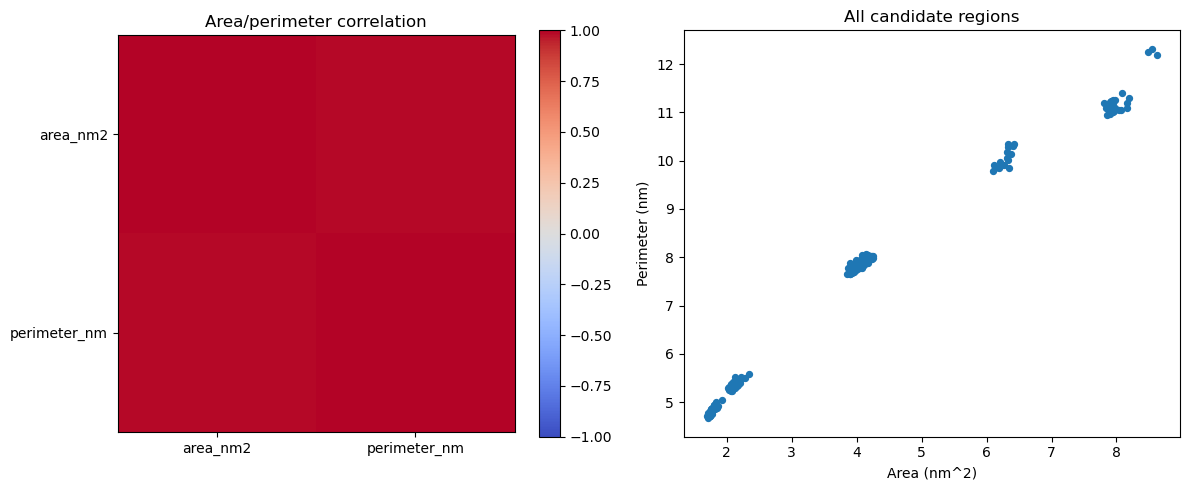

In [2]:
fig,axes = plt.subplots(1,2,figsize=(12,5))
correlation = features[FEATURES].corr()
im = axes[0].imshow(correlation,vmin=-1,vmax=1,cmap='coolwarm')
axes[0].set_xticks(range(len(FEATURES)),FEATURES)
axes[0].set_yticks(range(len(FEATURES)),FEATURES)
axes[0].set_title('Area/perimeter correlation')
fig.colorbar(im,ax=axes[0])
axes[1].scatter(raw[:,0],raw[:,1],s=18)
axes[1].set(xlabel='Area (nm^2)',ylabel='Perimeter (nm)',title='All candidate regions')
fig.tight_layout()
fig.savefig(OUT/'area_perimeter_diagnostics.png',dpi=160)
plt.show()


## 3. Fit four algorithms and select complexity

- **K-means:** fit k=2 through the declared maximum, select the highest mean silhouette. Fifty initialisations per k reduce random-start sensitivity.
- **Ward:** merge candidates using Ward linkage; select k over the same range using silhouette. This models hierarchical, compact groups.
- **GMM:** search 1 through the maximum and diagonal/tied/spherical covariance. Select minimum BIC among converged models. BIC penalises complexity; mixture components are not necessarily molecular classes. Full per-component covariance is excluded to limit complexity.
- **HDBSCAN:** find persistent dense groups without a requested k. Minimum group size and density parameters are declared above, not tuned to produce five. Label -1 means unassigned/noise, never a discarded object.

These are different selection rules, not a perfectly equal hyperparameter-search budget. A boundary optimum is reported. Silhouette-based selection cannot test the one-group hypothesis; GMM includes one component and HDBSCAN can return no accepted groups.


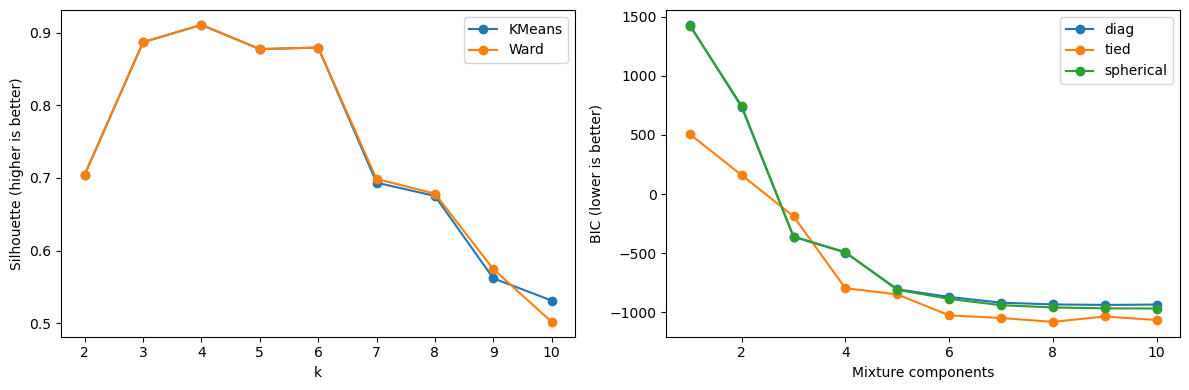

,k,selection,boundary,covariance,min_cluster_size,min_samples
KMeans,4,maximum silhouette,False,NaN,NaN,NaN
Ward,4,maximum silhouette,False,NaN,NaN,NaN
GMM,8,minimum BIC,False,tied,NaN,NaN
HDBSCAN,NaN,density persistence,False,NaN,10,5


In [3]:
results, configs, search_rows = {}, {}, []
def fit_labels(name, config, matrix, seed=SEED):
    if name == 'KMeans':
        return KMeans(n_clusters=config['k'],n_init=50,random_state=seed).fit_predict(matrix)
    if name == 'Ward':
        return AgglomerativeClustering(n_clusters=config['k'],linkage='ward').fit_predict(matrix)
    if name == 'GMM':
        model = GaussianMixture(n_components=config['k'],covariance_type=config['covariance'],
            n_init=10,max_iter=500,reg_covar=1e-5,random_state=seed).fit(matrix)
        if not model.converged_: raise ValueError('GMM did not converge')
        return model.predict(matrix)
    return HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,min_samples=MIN_SAMPLES).fit_predict(matrix)

with threadpool_limits(limits=1):
    for name in ['KMeans','Ward']:
        candidates = []
        for k in range(2,max_k+1):
            labels = fit_labels(name,{'k':k},X)
            score = float(silhouette_score(X,labels))
            search_rows.append(dict(method=name,k=k,criterion='silhouette',score=score,eligible=True))
            candidates.append((score,k,labels))
        score,k,labels = max(candidates,key=lambda item:(item[0],-item[1]))
        results[name],configs[name] = labels,{'k':int(k),'selection':'maximum silhouette','boundary':k in [2,max_k]}
    best = None
    for covariance in ['diag','tied','spherical']:
        for k in range(1,max_k+1):
            try:
                with warnings.catch_warnings(record=True) as caught:
                    warnings.simplefilter('always',ConvergenceWarning)
                    model = GaussianMixture(n_components=k,covariance_type=covariance,n_init=10,
                        max_iter=500,reg_covar=1e-5,random_state=SEED).fit(X)
                bic = float(model.bic(X))
                eligible = bool(model.converged_ and np.isfinite(bic))
                search_rows.append(dict(method='GMM',k=k,covariance=covariance,
                    criterion='BIC',score=bic,eligible=eligible,warnings=len(caught)))
                if eligible and (best is None or bic<best[0]): best=(bic,k,covariance,model)
            except (ValueError,np.linalg.LinAlgError) as error:
                search_rows.append(dict(method='GMM',k=k,covariance=covariance,criterion='BIC',
                    score=np.nan,eligible=False,error=str(error)))
    if best is None: raise RuntimeError('No eligible GMM model')
    bic,k,covariance,model = best
    results['GMM'] = model.predict(X)
    configs['GMM'] = {'k':int(k),'covariance':covariance,'selection':'minimum BIC','boundary':k in [1,max_k]}
    results['HDBSCAN'] = fit_labels('HDBSCAN',{},X)
    configs['HDBSCAN'] = {'min_cluster_size':MIN_CLUSTER_SIZE,'min_samples':MIN_SAMPLES,
                          'selection':'density persistence','boundary':False}
search = pd.DataFrame(search_rows)
search.to_csv(OUT/'model_selection.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name in ['KMeans','Ward']:
    table=search[search.method==name]
    axes[0].plot(table.k,table.score,'o-',label=name)
for covariance in ['diag','tied','spherical']:
    table=search[(search.method=='GMM')&(search.covariance==covariance)&search.eligible]
    axes[1].plot(table.k,table.score,'o-',label=covariance)
axes[0].set(xlabel='k',ylabel='Silhouette (higher is better)')
axes[1].set(xlabel='Mixture components',ylabel='BIC (lower is better)')
for ax in axes: ax.legend()
fig.tight_layout(); fig.savefig(OUT/'selection_curves.png',dpi=160); plt.show()
display(pd.DataFrame(configs).T)


## 4. Internal quality and conditional stability

Report silhouette, Calinski-Harabasz (higher), Davies-Bouldin (lower), group sizes and assigned coverage. HDBSCAN scores exclude noise and therefore are **not directly comparable** with full-coverage scores. Noise counts are reported separately.

For stability, sample 80% of objects 20 times, refit the scaler on each subset, and recluster with the selected configuration. Compare subset labels with the full-run labels using adjusted Rand index (ARI). This tests stability **conditional on the selected settings**, not stability of automatic k selection. For HDBSCAN, compare only objects assigned in both runs and report the fraction compared. Stability and internal quality do not establish chemical accuracy.


In [4]:
summary_rows, stability_rows = [], []
rng = np.random.default_rng(SEED)
subsets = [np.sort(rng.choice(len(ids),size=int(len(ids)*SAMPLE_FRACTION),replace=False))
           for _ in range(STABILITY_REPEATS)]
for name,labels in results.items():
    valid=labels>=0
    groups=np.unique(labels[valid]); counts=pd.Series(labels[valid]).value_counts()
    measurable=1<len(groups)<valid.sum()
    summary_rows.append(dict(method=name,n_candidates=len(ids),n_groups=len(groups),
        n_unassigned=int((~valid).sum()),coverage=float(valid.mean()),
        silhouette=float(silhouette_score(X[valid],labels[valid])) if measurable else np.nan,
        calinski_harabasz=float(calinski_harabasz_score(X[valid],labels[valid])) if measurable else np.nan,
        davies_bouldin=float(davies_bouldin_score(X[valid],labels[valid])) if measurable else np.nan,
        min_group_size=int(counts.min()) if len(counts) else 0,
        max_group_size=int(counts.max()) if len(counts) else 0,
        selection_boundary=configs[name]['boundary']))
    with threadpool_limits(limits=1):
        for repeat,subset in enumerate(subsets):
            try:
                subset_x=StandardScaler().fit_transform(raw[subset])
                predicted=fit_labels(name,configs[name],subset_x,SEED+repeat+1)
                reference=labels[subset]
                compared=(predicted>=0)&(reference>=0)
                meaningful=(compared.sum()>2 and len(np.unique(predicted[compared]))>1
                            and len(np.unique(reference[compared]))>1)
                ari=float(adjusted_rand_score(reference[compared],predicted[compared])) if meaningful else np.nan
                stability_rows.append(dict(method=name,repeat=repeat,ari=ari,
                    compared_fraction=float(compared.mean()),status='ok' if meaningful else 'insufficient_groups'))
            except (ValueError,np.linalg.LinAlgError) as error:
                stability_rows.append(dict(method=name,repeat=repeat,ari=np.nan,
                    compared_fraction=np.nan,status=str(error)))
summary=pd.DataFrame(summary_rows)
stability=pd.DataFrame(stability_rows)
stats=stability.groupby('method').agg(stability_ari_mean=('ari','mean'),stability_ari_std=('ari','std'),
    successful_stability_runs=('ari','count'),stability_compared_fraction=('compared_fraction','mean'))
summary=summary.merge(stats,on='method')
summary.to_csv(OUT/'algorithm_comparison.csv',index=False)
stability.to_csv(OUT/'subsample_stability.csv',index=False)
display(summary)
full=summary[(summary.coverage==1)&summary.silhouette.notna()]
if len(full):
    print('Highest full-coverage silhouette:',full.loc[full.silhouette.idxmax(),'method'])
print('This is an INTERNAL-score comparison, not a classification-accuracy ranking.')


,method,n_candidates,n_groups,n_unassigned,coverage,silhouette,calinski_harabasz,davies_bouldin,min_group_size,max_group_size,selection_boundary,stability_ari_mean,stability_ari_std,successful_stability_runs,stability_compared_fraction
0,KMeans,248,4,0,1.0,0.911035,9382.086576,0.170717,16,106,False,1.000000,0.000000,20,1.0
1,Ward,248,4,0,1.0,0.911035,9382.086576,0.170717,16,106,False,1.000000,0.000000,20,1.0
2,GMM,248,8,0,1.0,0.803112,20120.727259,0.582032,3,106,False,0.862118,0.075611,20,1.0
3,HDBSCAN,248,5,0,1.0,0.877585,14590.854729,0.214574,16,106,False,1.000000,0.000000,20,1.0


Highest full-coverage silhouette: KMeans
This is an INTERNAL-score comparison, not a classification-accuracy ranking.


## 5. Classification overlays, counts and representative candidates

Assign C1, C2, ... in ascending mean area **after fitting**, solely for readable plots. C1 in one method need not match C1 in another. Grey objects are unassigned, not missing detections. Export one row per original object, including unassigned objects. Display representative crops nearest each group's centroid in the two-dimensional standardised area/perimeter space; representatives are not a correctness check for every object.


,group_id,group_label,candidate_count,method
0,1,C1,99,KMeans
1,2,C2,106,KMeans
2,3,C3,16,KMeans
3,4,C4,27,KMeans


,group_id,group_label,candidate_count,method
0,1,C1,99,Ward
1,2,C2,106,Ward
2,3,C3,16,Ward
3,4,C4,27,Ward


,group_id,group_label,candidate_count,method
0,1,C1,32,GMM
1,2,C2,67,GMM
2,3,C3,106,GMM
3,4,C4,11,GMM
4,5,C5,5,GMM
5,6,C6,13,GMM
6,7,C7,11,GMM
7,8,C8,3,GMM


,group_id,group_label,candidate_count,method
0,1,C1,32,HDBSCAN
1,2,C2,67,HDBSCAN
2,3,C3,106,HDBSCAN
3,4,C4,16,HDBSCAN
4,5,C5,27,HDBSCAN


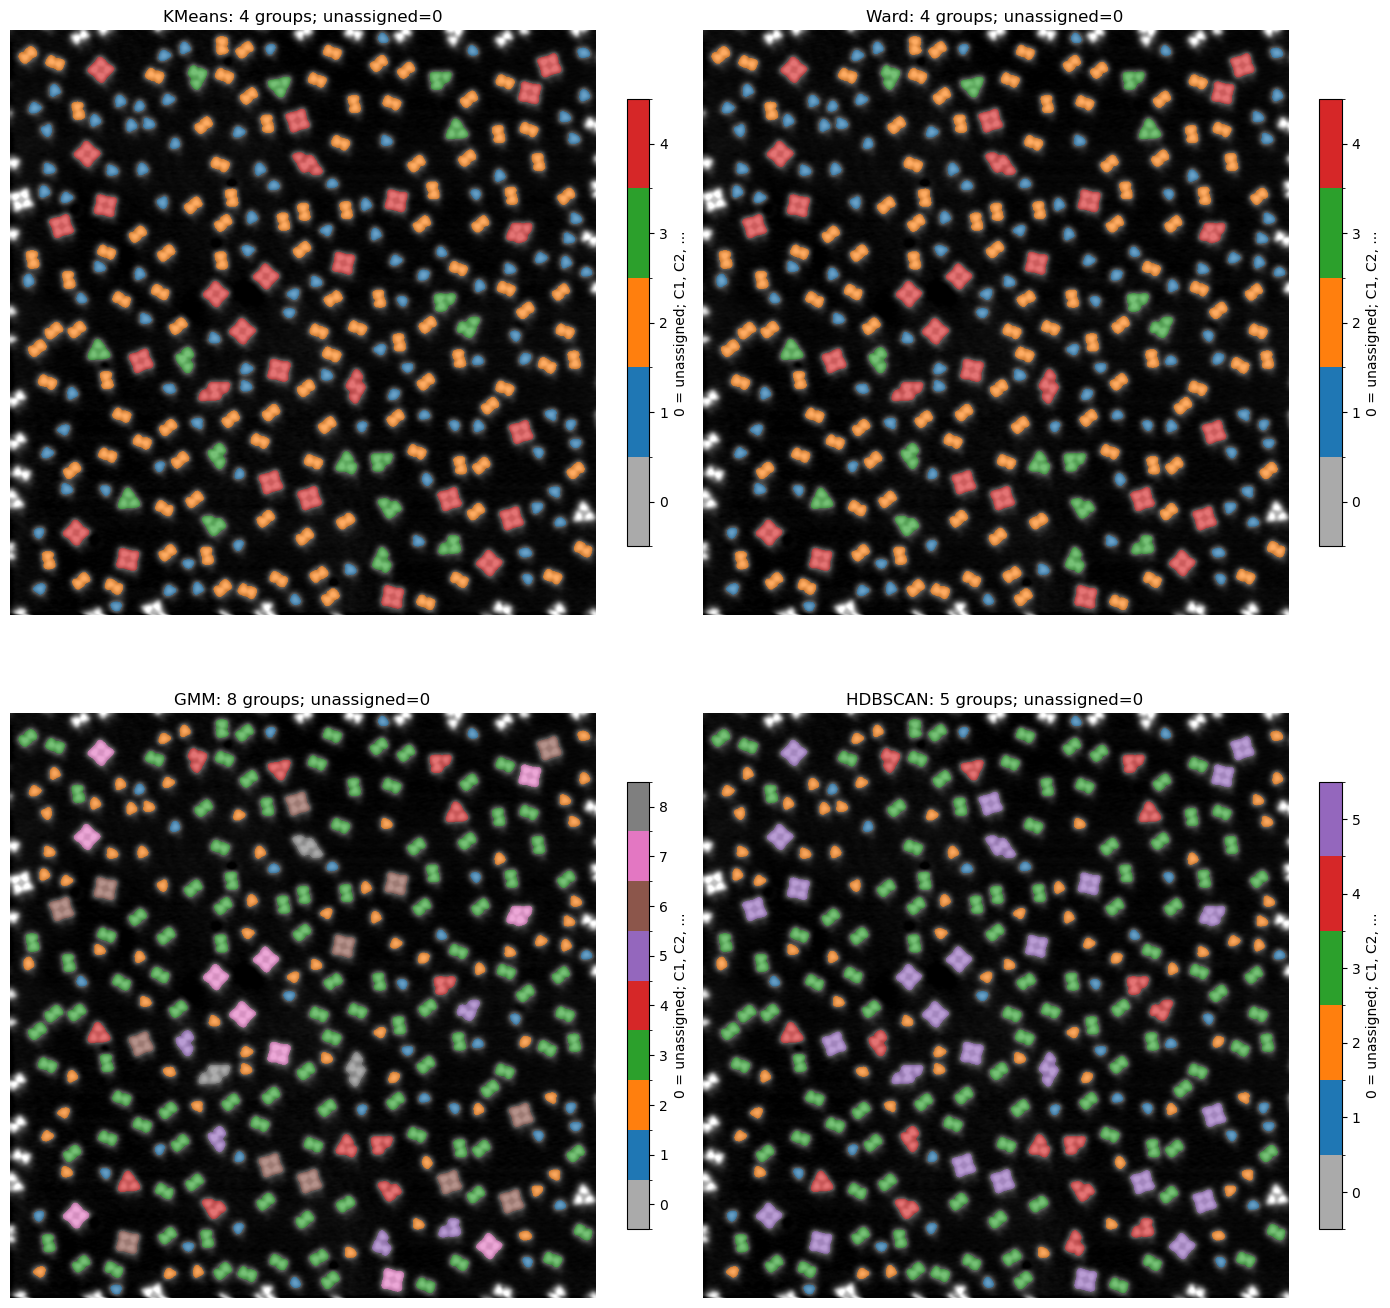

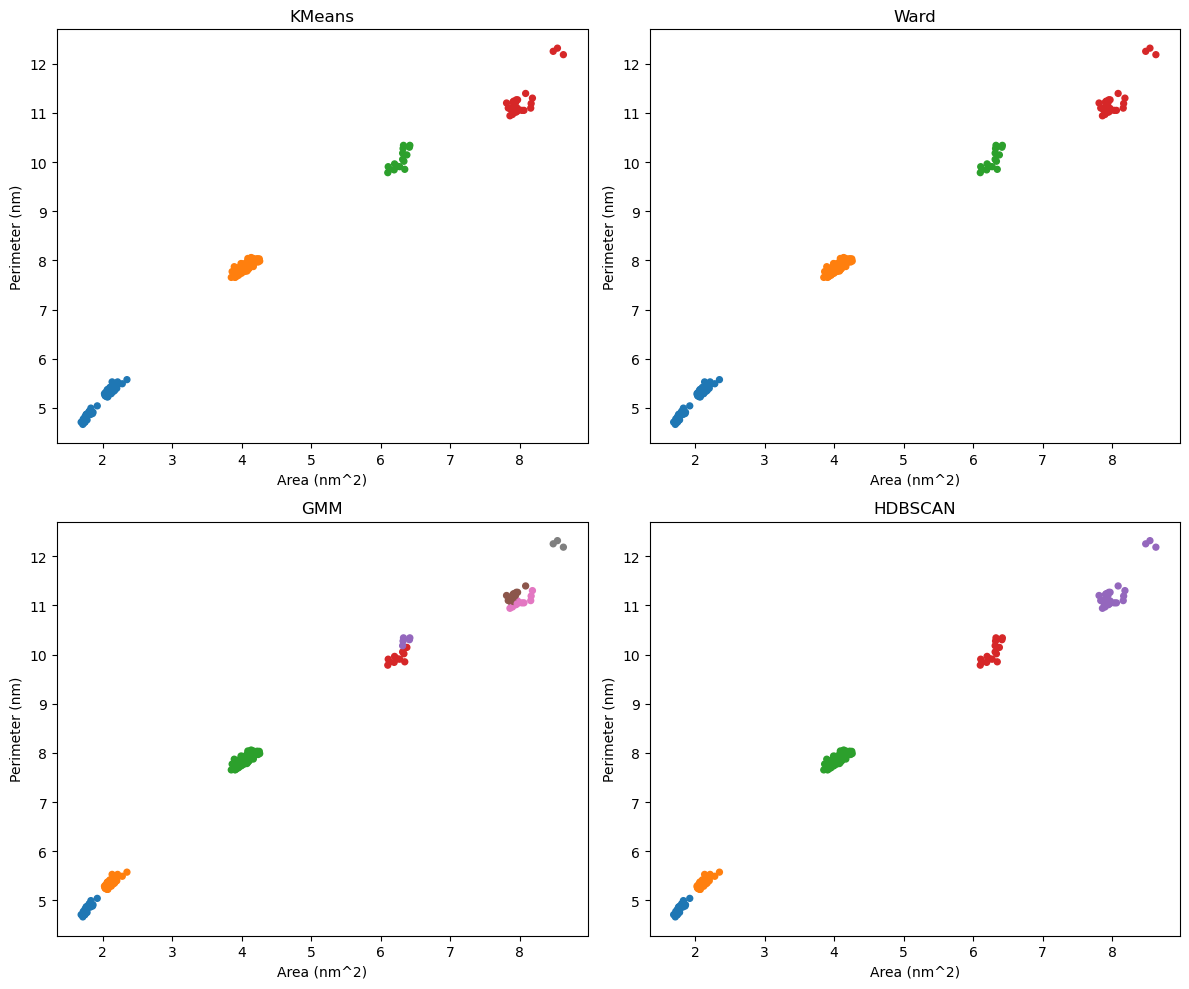

In [5]:
assignments_all=[]
fig,axes=plt.subplots(2,2,figsize=(14,14))
lo,hi=np.nanpercentile(height,[1,99])
for ax,(name,labels) in zip(axes.flat,results.items()):
    groups=sorted(set(labels)-{-1},key=lambda g:raw[labels==g,0].mean())
    mapping={g:i+1 for i,g in enumerate(groups)}
    readable=np.array([mapping.get(g,0) for g in labels])
    lookup=np.zeros(int(label_image.max())+1,dtype=int)
    lookup[ids]=readable
    cluster_map=lookup[label_image]
    np.save(OUT/f'{name}_cluster_image.npy',cluster_map)
    colors=['#aaaaaa']+[plt.get_cmap('tab10')(i%10) for i in range(len(groups))]
    cmap=ListedColormap(colors); norm=BoundaryNorm(np.arange(-.5,len(groups)+1.5),cmap.N)
    ax.imshow(height,cmap='gray',vmin=lo,vmax=hi)
    ax.imshow(np.ma.masked_where(label_image==0,cluster_map),cmap=cmap,norm=norm,alpha=.65)
    ax.set_title(f'{name}: {len(groups)} groups; unassigned={(labels<0).sum()}')
    ax.axis('off')
    fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap),ax=ax,fraction=.035,
                 ticks=range(len(groups)+1),label='0 = unassigned; C1, C2, ...')
    table=objects[['object_id','centroid_row','centroid_col']].copy()
    table['method']=name; table['raw_cluster_id']=labels; table['group_id']=readable
    table['group_label']=['Unassigned' if g==0 else f'C{g}' for g in readable]
    table.to_csv(OUT/f'{name}_assignments.csv',index=False); assignments_all.append(table)
    counts=table.groupby(['group_id','group_label']).size().reset_index(name='candidate_count')
    assert counts.candidate_count.sum()==len(ids)
    counts.to_csv(OUT/f'{name}_counts.csv',index=False)
    display(counts.assign(method=name))
    if groups:
        repfig,repaxes=plt.subplots(len(groups),4,figsize=(8,2*len(groups)),squeeze=False)
        for row,g in enumerate(groups):
            indexes=np.flatnonzero(labels==g)
            center=X[indexes].mean(axis=0)
            nearest=indexes[np.argsort(np.linalg.norm(X[indexes]-center,axis=1))[:4]]
            for col,a in enumerate(repaxes[row]):
                a.axis('off')
                if col>=len(nearest): continue
                index=nearest[col]; obj=objects.iloc[index]
                r0,c0=max(0,int(obj.min_row)-5),max(0,int(obj.min_col)-5)
                r1,c1=min(height.shape[0],int(obj.max_row)+5),min(height.shape[1],int(obj.max_col)+5)
                a.imshow(height[r0:r1,c0:c1],cmap='gray',vmin=lo,vmax=hi)
                a.set_title(f'C{mapping[g]} / ID {ids[index]}')
        repfig.suptitle(name+' representatives'); repfig.tight_layout()
        repfig.savefig(OUT/f'{name}_representatives.png',dpi=140); plt.close(repfig)
fig.tight_layout(); fig.savefig(OUT/'all_classification_overlays.png',dpi=160); plt.show()
assignments=pd.concat(assignments_all,ignore_index=True)
assignments.to_csv(OUT/'all_assignments.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(12,10))
for ax,(name,labels) in zip(axes.flat,results.items()):
    table=assignments[assignments.method==name].set_index('object_id').loc[ids]
    readable=table.group_id.to_numpy()
    n_groups=int(readable.max())
    colors=['#aaaaaa']+[plt.get_cmap('tab10')(i%10) for i in range(n_groups)]
    cmap=ListedColormap(colors)
    norm=BoundaryNorm(np.arange(-.5,n_groups+1.5),cmap.N)
    ax.scatter(raw[:,0],raw[:,1],c=readable,cmap=cmap,norm=norm,s=18)
    ax.set(title=name,xlabel='Area (nm^2)',ylabel='Perimeter (nm)')
fig.tight_layout(); fig.savefig(OUT/'all_area_perimeter_scatter.png',dpi=160); plt.show()


## 6. Manual reference counts and optional object-level evaluation

The reference below is supplied by the user, not newly independently annotated. It distinguishes interior counts, ten border objects and three overlapping P2 objects. The interior reference totals 248, but matching this total does **not** establish that P1 detected exactly the same objects.

Only if a method produces five occupied groups with no unassigned objects do we compare its sorted count profile with the sorted interior reference. The pairing minimises aggregate count discrepancy and is **not a chemical label mapping or accuracy estimate**. Other outcomes remain not comparable under this narrow five-group count-profile test.

For actual object-level evaluation, optionally provide `Notebooks/P3/manual_labels_alternative1.csv` with unique `object_id,true_label` rows. Independently annotate labels before consulting model predictions. Only labelled objects are evaluated, and the coverage is reported. ARI/NMI compare partitions without requiring group names. One-to-one mapped agreement uses a best mapping on these same evaluation labels and is descriptive, not held-out predictive accuracy. Noise counts as incorrect for mapped agreement.


Candidate IDs are specific to this preprocessing method. Never reuse labels from another method without spatial matching. Border/overlap inclusion rules may differ from the interior manual reference.


In [6]:
reference=pd.DataFrame({
    'class':['Dimer of P1','Trimer of P1','Tetramer of P1','P2','P3'],
    'interior_count':[106,16,27,67,32], 'border_count':[8,1,1,0,0],
    'overlap_additional_count':[0,0,0,3,0]})
reference['inclusive_count']=reference[['interior_count','border_count','overlap_additional_count']].sum(axis=1)
reference.to_csv(OUT/'manual_reference_counts.csv',index=False)
display(reference)
reference_profile=np.sort(reference.interior_count.to_numpy())
count_rows=[]
for name,labels in results.items():
    counts=pd.Series(labels[labels>=0]).value_counts().to_numpy()
    comparable=len(counts)==5 and (labels>=0).all()
    count_rows.append(dict(method=name,comparable_five_group_profile=comparable,
        sorted_count_absolute_error=int(np.abs(np.sort(counts)-reference_profile).sum()) if comparable else np.nan,
        candidate_total_difference=int(len(ids)-reference.interior_count.sum())))
display(pd.DataFrame(count_rows))
pd.DataFrame(count_rows).to_csv(OUT/'aggregate_count_reference_comparison.csv',index=False)
manual_path=ROOT/'Notebooks/P3/manual_labels_alternative1.csv'
pd.DataFrame({'object_id':ids,'true_label':''}).to_csv(OUT/'manual_labels_template.csv',index=False)
external=[]
if manual_path.exists():
    manual=pd.read_csv(manual_path,dtype={'true_label':'string'})
    assert {'object_id','true_label'}<=set(manual.columns)
    assert manual.object_id.is_unique and set(manual.object_id)<=set(ids)
    manual=manual.dropna(subset=['true_label'])
    manual=manual[manual.true_label.str.strip()!='']
    for name,labels in results.items():
        joined=pd.DataFrame({'object_id':ids,'predicted':labels}).merge(manual,on='object_id')
        if len(joined)<2: continue
        assigned=joined.predicted>=0
        contingency=pd.crosstab(joined.loc[assigned,'predicted'],joined.loc[assigned,'true_label'])
        if contingency.size:
            rows,cols=linear_sum_assignment(-contingency.to_numpy())
            correct=int(contingency.to_numpy()[rows,cols].sum())
        else: correct=0
        external.append(dict(method=name,labelled_objects=len(joined),label_coverage=len(joined)/len(ids),
            labelled_assignment_coverage=float(assigned.mean()),
            ARI_including_noise=float(adjusted_rand_score(joined.true_label,joined.predicted)),
            NMI_including_noise=float(normalized_mutual_info_score(joined.true_label,joined.predicted)),
            mapped_agreement=correct/len(joined)))
if external:
    evaluation=pd.DataFrame(external); display(evaluation)
    evaluation.to_csv(OUT/'object_label_evaluation.csv',index=False)
else:
    print('No usable object-level labels: classification accuracy is unavailable.')
    (OUT/'object_label_evaluation.csv').unlink(missing_ok=True)


,class,interior_count,border_count,overlap_additional_count,inclusive_count
0,Dimer of P1,106,8,0,114
1,Trimer of P1,16,1,0,17
2,Tetramer of P1,27,1,0,28
3,P2,67,0,3,70
4,P3,32,0,0,32


,method,comparable_five_group_profile,sorted_count_absolute_error,candidate_total_difference
0,KMeans,False,NaN,0
1,Ward,False,NaN,0
2,GMM,False,NaN,0
3,HDBSCAN,True,0.0,0


No usable object-level labels: classification accuracy is unavailable.


## 7. Interpretation and reproducibility checks

Read results in this order: (1) coverage and candidate failures; (2) overlays and representatives; (3) internal separation; (4) stability and compared coverage; (5) independent manual labels, if available. Do not select a method simply because it reports five groups. Similar internal scores, boundary optima or unstable assignments warrant more evidence, not a forced winner.

The algorithms and scalers are fitted on this scan. This is exploratory in-sample clustering, not a supervised train/test experiment or a demonstration of transfer to other scans. HDBSCAN noise may include valid molecules. Area/perimeter correlation and segmentation quality remain possible confounders; height is not a clustering input. Border fragments, overlaps and segmentation errors inherited from preprocessing are not repaired by clustering.


In [7]:
assert input_hashes == {name:sha(P1/name) for name in INPUTS}
assert len(assignments)==len(ids)*len(results)
for name,table in assignments.groupby('method'):
    assert table.object_id.is_unique and set(table.object_id)==set(ids)
assert set(results)=={'KMeans','Ward','GMM','HDBSCAN'}
for name in ['KMeans','Ward']:
    table=search[search.method==name]
    assert configs[name]['k']==int(table.loc[table.score.idxmax(),'k'])
manifest={'input_directory':str(P1.relative_to(ROOT)),'input_hashes':input_hashes,
    'features':FEATURES,'n_candidates':len(ids),'seed':SEED,'max_k':max_k,
    'configs':configs,'stability_repeats':STABILITY_REPEATS,'sample_fraction':SAMPLE_FRACTION,
    'manual_labels_used_for_fitting':False,'feature_scope':'area_and_perimeter_only','dimensionality_reduction':False,
    'manual_label_file_sha256':sha(manual_path) if manual_path.exists() else None,
    'python':platform.python_version(),'sklearn':sklearn.__version__,
    'numpy':np.__version__,'results':json.loads(summary.to_json(orient='records'))}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2,allow_nan=False))
print('Verified: P1 unchanged; each candidate has one assignment per method.')
print('Outputs:',OUT.relative_to(ROOT))


Verified: P1 unchanged; each candidate has one assignment per method.
Outputs: Notebooks/P3/outputs/alternative1_area_perimeter_clustering
